# Cycle Time → Beam State (ISIS RCS)

This module provides a clean, physics-consistent way to convert **cycle time** into a full **beam state** for the ISIS RCS.

---

# Physical Model

The ISIS main magnets operate with a **50 Hz AC sinusoidal ramp**, so the beam momentum follows:

$$
p_n(t) = \frac{1}{2} \left( p_r + 1 - (p_r - 1)\cos(\pi f) \right)
$$

where:

- $p_n(t)$ = normalised momentum  
- $p_r = \frac{p_{\text{top}}}{p_{\text{inj}}}$  
- $f = \frac{t - t_0}{t_1 - t_0}$ = normalised cycle time  

Momentum is then:

$$
p(t) = p_{\text{inj}} \cdot p_n(t)
$$

Total energy:

$$
E_{\text{tot}} = \sqrt{p^2 + m^2}
$$

Kinetic energy:

$$
E_{\text{kin}} = E_{\text{tot}} - m
$$

Relativistic parameters:

$$
\gamma = \frac{E_{\text{tot}}}{m}, \quad
\beta = \sqrt{1 - \frac{1}{\gamma^2}}
$$

Magnetic rigidity:

$$
B\rho = \frac{p}{0.299792458} \quad \text{(with } p \text{ in GeV/c)}
$$

# Classes

## 1. `RCSRamp`

This is the **core physics engine**.

It converts:

```
cycle time → momentum → energy → gamma/beta → Brho
```

### Example

```python
ramp = RCSRamp(top_energy_MeV=800)
```

---

### Get values at a single time

```python
state = ramp.state_at(5.0)   # time in ms
```

---

### Direct access methods

```python
ramp.energy_at(t)
ramp.momentum_at(t)
ramp.gamma_at(t)
ramp.beta_at(t)
ramp.brho_at(t)
ramp.normalised_momentum_at(t)
```

All methods accept scalars or arrays.

---

### Vectorised usage

```python
t = np.linspace(0, 10, 100)

energy = ramp.energy_at(t)
momentum = ramp.momentum_at(t)
pn = ramp.normalised_momentum_at(t)
```

---

### Full cycle as DataFrame

```python
df = ramp.full_cycle_dataframe(intervals=100)
```

This returns:

```
cycle_time_ms
kinetic_energy_MeV
kinetic_energy_GeV
total_energy_MeV
total_energy_GeV
gamma
beta
momentum_MeV_c
momentum_GeV_c
brho_Tm
normalised_momentum
```

---

## 2. `RCSState`

This is a **read-only snapshot of beam parameters at one time**.

Created via:

```python
state = ramp.state_at(t)
```

---

### Access values

```python
state.gamma
state.beta
state.momentum_MeV_c
state.brho_Tm
```

---

### Convenience methods

```python
state.kinetic_energy_GeV()
state.total_energy_GeV()
state.momentum_GeV_c()
```

---

### Print summary

```python
state.print_beam()
```

---

### Convert to dictionary

```python
state.summary_dict()
```

Useful for building DataFrames.

---

# Design Philosophy

## Separation of responsibilities

```
RCSRamp  → computes physics
RCSState → stores results
```

---

## Key principles

- **Single source of truth**: sinusoidal AC ramp only  
- **No duplicated physics**  
- **Consistent units (MeV, GeV, Tm)**  
- **Immutable state (safe for downstream use)**  

---

# Typical Workflow

```python
ramp = RCSRamp(top_energy_MeV=800)

# Single time
state = ramp.state_at(3.0)

# Many times
df = ramp.full_cycle_dataframe(intervals=100)

# Feed into next stage
# → strength scaling
# → MAD-X model
# → optics / envelope / tune
```

---

# What Comes Next

This module feeds directly into:

```
cycle_time → strength_scaling → MAD-X → optics → matching
```

So this is the **foundation layer** of the entire optics GUI / modelling framework.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cycle_time import (
    PROTON_REST_MASS_MEV,
    SPEED_OF_LIGHT,
    GEV_PER_MEV,
    DEFAULT_INJECTION_ENERGY_MEV,
    DEFAULT_TOP_ENERGY_MEV,
    DEFAULT_CYCLE_START_MS,
    DEFAULT_CYCLE_END_MS,
    DEFAULT_RAMP_FREQUENCY_HZ,
    lorentz_gamma,
    lorentz_gamma_from_beta,
    lorentz_beta,
    total_energy_from_gamma_MeV,
    total_energy_from_kinetic_MeV,
    kinetic_energy_from_total_MeV,
    momentum_from_total_energy_MeV_c,
    momentum_from_kinetic_energy_MeV_c,
    relativistic_momentum_MeV_c,
    brho_from_momentum_MeV_c,
    momentum_from_brho_MeV_c,
    RCSState,
    RCSRamp,
)

In [2]:
# ============================================================
# 1. Constants
# ============================================================

print("Constants")
print("---------")
print("PROTON_REST_MASS_MEV =", PROTON_REST_MASS_MEV)
print("SPEED_OF_LIGHT =", SPEED_OF_LIGHT)
print("GEV_PER_MEV =", GEV_PER_MEV)
print("DEFAULT_INJECTION_ENERGY_MEV =", DEFAULT_INJECTION_ENERGY_MEV)
print("DEFAULT_TOP_ENERGY_MEV =", DEFAULT_TOP_ENERGY_MEV)
print("DEFAULT_CYCLE_START_MS =", DEFAULT_CYCLE_START_MS)
print("DEFAULT_CYCLE_END_MS =", DEFAULT_CYCLE_END_MS)
print("DEFAULT_RAMP_FREQUENCY_HZ =", DEFAULT_RAMP_FREQUENCY_HZ)

Constants
---------
PROTON_REST_MASS_MEV = 938.27208816
SPEED_OF_LIGHT = 299792458.0
GEV_PER_MEV = 0.001
DEFAULT_INJECTION_ENERGY_MEV = 70.0
DEFAULT_TOP_ENERGY_MEV = 800.0
DEFAULT_CYCLE_START_MS = 0.0
DEFAULT_CYCLE_END_MS = 10.0
DEFAULT_RAMP_FREQUENCY_HZ = 50.0


In [3]:
# ============================================================
# 2. Relativistic helper functions
# ============================================================

kinetic_energy_MeV = 70.0
total_energy_MeV = total_energy_from_kinetic_MeV(kinetic_energy_MeV)

gamma = lorentz_gamma(total_energy_MeV)
beta = lorentz_beta(gamma)
gamma_from_beta = lorentz_gamma_from_beta(beta)

momentum_from_total = momentum_from_total_energy_MeV_c(total_energy_MeV)
momentum_from_kinetic = momentum_from_kinetic_energy_MeV_c(kinetic_energy_MeV)
momentum_from_gamma = relativistic_momentum_MeV_c(gamma)

brho = brho_from_momentum_MeV_c(momentum_from_kinetic)
momentum_from_brho = momentum_from_brho_MeV_c(brho)

total_from_gamma = total_energy_from_gamma_MeV(gamma)
kinetic_from_total = kinetic_energy_from_total_MeV(total_energy_MeV)

print("\nRelativistic helper function checks")
print("----------------------------------")
print("Kinetic energy [MeV] =", kinetic_energy_MeV)
print("Total energy [MeV] =", total_energy_MeV)
print("Gamma =", gamma)
print("Beta =", beta)
print("Gamma from beta =", gamma_from_beta)
print("Momentum from total energy [MeV/c] =", momentum_from_total)
print("Momentum from kinetic energy [MeV/c] =", momentum_from_kinetic)
print("Momentum from gamma [MeV/c] =", momentum_from_gamma)
print("Brho [Tm] =", brho)
print("Momentum from Brho [MeV/c] =", momentum_from_brho)
print("Total energy from gamma [MeV] =", total_from_gamma)
print("Kinetic energy from total [MeV] =", kinetic_from_total)

assert np.isclose(gamma, gamma_from_beta)
assert np.isclose(momentum_from_total, momentum_from_kinetic)
assert np.isclose(momentum_from_total, momentum_from_gamma)
assert np.isclose(momentum_from_kinetic, momentum_from_brho)
assert np.isclose(total_energy_MeV, total_from_gamma)
assert np.isclose(kinetic_energy_MeV, kinetic_from_total)

print("\nAll helper-function assertions passed.")



Relativistic helper function checks
----------------------------------
Kinetic energy [MeV] = 70.0
Total energy [MeV] = 1008.27208816
Gamma = 1.0746052247352615
Beta = 0.3661031008687554
Gamma from beta = 1.0746052247352615
Momentum from total energy [MeV/c] = 369.13153799479124
Momentum from kinetic energy [MeV/c] = 369.13153799479124
Momentum from gamma [MeV/c] = 369.1315379947911
Brho [Tm] = 1.2312902748033483
Momentum from Brho [MeV/c] = 369.13153799479124
Total energy from gamma [MeV] = 1008.2720881599998
Kinetic energy from total [MeV] = 70.0

All helper-function assertions passed.


In [4]:
# ============================================================
# 3. RCSState direct construction and methods
# ============================================================

state_manual = RCSState(
    cycle_time_ms=0.0,
    kinetic_energy_MeV=kinetic_energy_MeV,
    total_energy_MeV=total_energy_MeV,
    gamma=gamma,
    beta=beta,
    momentum_MeV_c=momentum_from_kinetic,
    brho_Tm=brho,
    normalised_momentum=1.0,
)

print("\nManual RCSState")
print("---------------")
print(state_manual)

print("\nRCSState methods")
print("----------------")
print("kinetic_energy_GeV() =", state_manual.kinetic_energy_GeV())
print("total_energy_GeV() =", state_manual.total_energy_GeV())
print("momentum_GeV_c() =", state_manual.momentum_GeV_c())
print("summary_dict() =")
print(state_manual.summary_dict())

print("\nprint_beam():")
state_manual.print_beam()

assert np.isclose(state_manual.kinetic_energy_GeV(), state_manual.kinetic_energy_MeV / 1000.0)
assert np.isclose(state_manual.total_energy_GeV(), state_manual.total_energy_MeV / 1000.0)
assert np.isclose(state_manual.momentum_GeV_c(), state_manual.momentum_MeV_c / 1000.0)

print("\nAll RCSState assertions passed.")


Manual RCSState
---------------
RCSState(t=0 ms, E_kin=70 MeV, p=0.369132 GeV/c, Brho=1.23129 Tm, pn=1)

RCSState methods
----------------
kinetic_energy_GeV() = 0.07
total_energy_GeV() = 1.00827208816
momentum_GeV_c() = 0.36913153799479126
summary_dict() =
{'cycle_time_ms': 0.0, 'kinetic_energy_MeV': 70.0, 'kinetic_energy_GeV': 0.07, 'total_energy_MeV': 1008.27208816, 'total_energy_GeV': 1.00827208816, 'gamma': 1.0746052247352615, 'beta': np.float64(0.3661031008687554), 'momentum_MeV_c': np.float64(369.13153799479124), 'momentum_GeV_c': np.float64(0.36913153799479126), 'brho_Tm': np.float64(1.2312902748033483), 'normalised_momentum': 1.0}

print_beam():
M_proton = 938.27209 MeV
Cycle time = 0 ms
Energy = 0.07 GeV
Energy = 70 MeV
Total energy = 1.0082721 GeV
Gamma = 1.0746052
Beta = 0.3661031
Momentum = 0.36913154 GeV/c
Rigidity = 1.2312903 Tm
Normalised momentum = 1

All RCSState assertions passed.


In [6]:
# ============================================================
# 4. RCSRamp: sinusoidal default ramp
# ============================================================

ramp = RCSRamp(
    top_energy_MeV=800.0,
    injection_energy_MeV=70.0,
    cycle_start_ms=0.0,
    cycle_end_ms=10.0,
)

print("\nRCSRamp object")
print("--------------")
print("top_energy_MeV =", ramp.top_energy_MeV)
print("injection_energy_MeV =", ramp.injection_energy_MeV)
print("cycle_start_ms =", ramp.cycle_start_ms)
print("cycle_end_ms =", ramp.cycle_end_ms)
print("ramp_frequency_Hz =", ramp.ramp_frequency_Hz)
print("rest_mass_MeV =", ramp.rest_mass_MeV)
print("injection_momentum_MeV_c =", ramp.injection_momentum_MeV_c)
print("top_momentum_MeV_c =", ramp.top_momentum_MeV_c)
print("momentum_ratio =", ramp.momentum_ratio)



RCSRamp object
--------------
top_energy_MeV = 800.0
injection_energy_MeV = 70.0
cycle_start_ms = 0.0
cycle_end_ms = 10.0
ramp_frequency_Hz = 50.0
rest_mass_MeV = 938.27208816
injection_momentum_MeV_c = 369.13153799479124
top_momentum_MeV_c = 1463.29605379636
momentum_ratio = 3.964158851734333


In [7]:
# ============================================================
# 5. RCSRamp scalar methods
# ============================================================

test_times = [0.0, 2.5, 5.0, 7.5, 10.0]

print("\nRCSRamp scalar method checks")
print("---------------------------")

for t in test_times:
    print("\nTime =", t, "ms")
    print("ramp_fraction_at =", ramp.ramp_fraction_at(t))
    print("normalised_momentum_at =", ramp.normalised_momentum_at(t))
    print("momentum_at [MeV/c] =", ramp.momentum_at(t))
    print("total_energy_at [MeV] =", ramp.total_energy_at(t))
    print("energy_at [MeV] =", ramp.energy_at(t))
    print("kinetic_energy_at [MeV] =", ramp.kinetic_energy_at(t))
    print("gamma_at =", ramp.gamma_at(t))
    print("beta_at =", ramp.beta_at(t))
    print("brho_at [Tm] =", ramp.brho_at(t))

    assert np.isclose(ramp.energy_at(t), ramp.kinetic_energy_at(t))
    assert np.isclose(
        ramp.normalised_momentum_at(t),
        ramp.momentum_at(t) / ramp.injection_momentum_MeV_c,
    )
    assert np.isclose(
        ramp.brho_at(t),
        brho_from_momentum_MeV_c(ramp.momentum_at(t)),
    )

print("\nAll scalar RCSRamp assertions passed.")


RCSRamp scalar method checks
---------------------------

Time = 0.0 ms
ramp_fraction_at = 0.0
normalised_momentum_at = 1.0
momentum_at [MeV/c] = 369.13153799479124
total_energy_at [MeV] = 1008.27208816
energy_at [MeV] = 70.0
kinetic_energy_at [MeV] = 70.0
gamma_at = 1.0746052247352615
beta_at = 0.3661031008687554
brho_at [Tm] = 1.2312902748033483

Time = 2.5 ms
ramp_fraction_at = 0.25
normalised_momentum_at = 1.434091013579428
momentum_at [MeV/c] = 529.3682214670833
total_energy_at [MeV] = 1077.3046112030477
energy_at [MeV] = 139.03252304304772
kinetic_energy_at [MeV] = 139.03252304304772
gamma_at = 1.1481793232448145
beta_at = 0.4913821178913615
brho_at [Tm] = 1.7657823182032266

Time = 5.0 ms
ramp_fraction_at = 0.5
normalised_momentum_at = 2.4820794258671666
momentum_at [MeV/c] = 916.2137958955757
total_energy_at [MeV] = 1311.4123040483898
energy_at [MeV] = 373.1402158883899
kinetic_energy_at [MeV] = 373.1402158883899
gamma_at = 1.3976887094873909
beta_at = 0.6986466369632051
brho_

In [8]:
# ============================================================
# 6. RCSRamp endpoint tests
# ============================================================

state_start = ramp.state_at(0.0)
state_mid = ramp.state_at(5.0)
state_end = ramp.state_at(10.0)

print("\nEndpoint states")
print("---------------")
print("Start:", state_start)
print("Mid:  ", state_mid)
print("End:  ", state_end)

assert np.isclose(state_start.kinetic_energy_MeV, 70.0)
assert np.isclose(state_end.kinetic_energy_MeV, 800.0)
assert np.isclose(state_start.normalised_momentum, 1.0)
assert np.isclose(state_end.normalised_momentum, ramp.momentum_ratio)

print("\nEndpoint assertions passed.")


Endpoint states
---------------
Start: RCSState(t=0 ms, E_kin=70 MeV, p=0.369132 GeV/c, Brho=1.23129 Tm, pn=1)
Mid:   RCSState(t=5 ms, E_kin=373.14 MeV, p=0.916214 GeV/c, Brho=3.05616 Tm, pn=2.48208)
End:   RCSState(t=10 ms, E_kin=800 MeV, p=1.4633 GeV/c, Brho=4.88103 Tm, pn=3.96416)

Endpoint assertions passed.


In [9]:
# ============================================================
# 7. RCSRamp.state_at()
# ============================================================

state = ramp.state_at(3.0)

print("\nstate_at(3.0)")
print("-------------")
print(state)
print(state.summary_dict())

assert isinstance(state, RCSState)
assert np.isclose(state.cycle_time_ms, 3.0)
assert np.isclose(state.kinetic_energy_MeV, ramp.energy_at(3.0))
assert np.isclose(state.total_energy_MeV, ramp.total_energy_at(3.0))
assert np.isclose(state.gamma, ramp.gamma_at(3.0))
assert np.isclose(state.beta, ramp.beta_at(3.0))
assert np.isclose(state.momentum_MeV_c, ramp.momentum_at(3.0))
assert np.isclose(state.brho_Tm, ramp.brho_at(3.0))
assert np.isclose(state.normalised_momentum, ramp.normalised_momentum_at(3.0))

print("\nstate_at() assertions passed.")


state_at(3.0)
-------------
RCSState(t=3 ms, E_kin=172.565 MeV, p=0.594647 GeV/c, Brho=1.98353 Tm, pn=1.61093)
{'cycle_time_ms': 3.0, 'kinetic_energy_MeV': 172.56519175739015, 'kinetic_energy_GeV': 0.17256519175739016, 'total_energy_MeV': 1110.83727991739, 'total_energy_GeV': 1.1108372799173902, 'gamma': 1.1839180701791945, 'beta': 0.5353141487606986, 'momentum_MeV_c': 594.6469129106272, 'momentum_GeV_c': 0.5946469129106272, 'brho_Tm': 1.983528594674077, 'normalised_momentum': 1.6109349966163502}

state_at() assertions passed.


In [10]:
# ============================================================
# 8. RCSRamp.states_at()
# ============================================================

states = ramp.states_at(test_times)

print("\nstates_at(test_times)")
print("---------------------")

for s in states:
    print(s)

assert len(states) == len(test_times)
assert all(isinstance(s, RCSState) for s in states)

print("\nstates_at() assertions passed.")


states_at(test_times)
---------------------
RCSState(t=0 ms, E_kin=70 MeV, p=0.369132 GeV/c, Brho=1.23129 Tm, pn=1)
RCSState(t=2.5 ms, E_kin=139.033 MeV, p=0.529368 GeV/c, Brho=1.76578 Tm, pn=1.43409)
RCSState(t=5 ms, E_kin=373.14 MeV, p=0.916214 GeV/c, Brho=3.05616 Tm, pn=2.48208)
RCSState(t=7.5 ms, E_kin=667.442 MeV, p=1.30306 GeV/c, Brho=4.34654 Tm, pn=3.53007)
RCSState(t=10 ms, E_kin=800 MeV, p=1.4633 GeV/c, Brho=4.88103 Tm, pn=3.96416)

states_at() assertions passed.


In [11]:
# ============================================================
# 9. RCSRamp.dataframe_at()
# ============================================================

df = ramp.dataframe_at(test_times)

print("\ndataframe_at(test_times)")
print("------------------------")
display(df)

expected_columns = [
    "cycle_time_ms",
    "kinetic_energy_MeV",
    "kinetic_energy_GeV",
    "total_energy_MeV",
    "total_energy_GeV",
    "gamma",
    "beta",
    "momentum_MeV_c",
    "momentum_GeV_c",
    "brho_Tm",
    "normalised_momentum",
]

assert list(df.columns) == expected_columns
assert len(df) == len(test_times)

print("\ndataframe_at() assertions passed.")


dataframe_at(test_times)
------------------------


,cycle_time_ms,kinetic_energy_MeV,kinetic_energy_GeV,total_energy_MeV,total_energy_GeV,gamma,beta,momentum_MeV_c,momentum_GeV_c,brho_Tm,normalised_momentum
0,0.0,70.000000,0.070000,1008.272088,1.008272,1.074605,0.366103,369.131538,0.369132,1.231290,1.000000
1,2.5,139.032523,0.139033,1077.304611,1.077305,1.148179,0.491382,529.368221,0.529368,1.765782,1.434091
2,5.0,373.140216,0.373140,1311.412304,1.311412,1.397689,0.698647,916.213796,0.916214,3.056160,2.482079
3,7.5,667.442156,0.667442,1605.714244,1.605714,1.711352,0.811514,1303.059370,1.303059,4.346538,3.530068
4,10.0,800.000000,0.800000,1738.272088,1.738272,1.852631,0.841811,1463.296054,1.463296,4.881030,3.964159



dataframe_at() assertions passed.


In [12]:
# ============================================================
# 10. RCSRamp.full_cycle_dataframe()
# ============================================================

df_full = ramp.full_cycle_dataframe(intervals=20)

print("\nfull_cycle_dataframe(intervals=20)")
print("---------------------------------")
display(df_full)

assert len(df_full) == 21
assert np.isclose(df_full["cycle_time_ms"].iloc[0], 0.0)
assert np.isclose(df_full["cycle_time_ms"].iloc[-1], 10.0)
assert np.isclose(df_full["kinetic_energy_MeV"].iloc[0], 70.0)
assert np.isclose(df_full["kinetic_energy_MeV"].iloc[-1], 800.0)

print("\nfull_cycle_dataframe() assertions passed.")


full_cycle_dataframe(intervals=20)
---------------------------------


,cycle_time_ms,kinetic_energy_MeV,kinetic_energy_GeV,total_energy_MeV,total_energy_GeV,gamma,beta,momentum_MeV_c,momentum_GeV_c,brho_Tm,normalised_momentum
0,0.0,70.000000,0.070000,1008.272088,1.008272,1.074605,0.366103,369.131538,0.369132,1.231290,1.000000
1,0.5,72.485318,0.072485,1010.757406,1.010757,1.077254,0.371867,375.867028,0.375867,1.253757,1.018247
2,1.0,80.107693,0.080108,1018.379781,1.018380,1.085378,0.388762,395.907650,0.395908,1.320606,1.072538
3,1.5,93.323566,0.093324,1031.595654,1.031596,1.099463,0.415628,428.759935,0.428760,1.430189,1.161537
4,2.0,112.758660,0.112759,1051.030748,1.051031,1.120177,0.450620,473.614952,0.473615,1.579809,1.283052
5,2.5,139.032523,0.139033,1077.304611,1.077305,1.148179,0.491382,529.368221,0.529368,1.765782,1.434091
6,3.0,172.565192,0.172565,1110.837280,1.110837,1.183918,0.535314,594.646913,0.594647,1.983529,1.610935
7,3.5,213.409139,0.213409,1151.681228,1.151681,1.227449,0.579886,667.843648,0.667844,2.227687,1.809229
8,4.0,261.143070,0.261143,1199.415158,1.199415,1.278323,0.622934,747.156081,0.747156,2.492244,2.024092
9,4.5,314.845156,0.314845,1253.117244,1.253117,1.335558,0.662852,830.631276,0.830631,2.770688,2.250231



full_cycle_dataframe() assertions passed.


In [13]:

# ============================================================
# 11. Vectorised array usage
# ============================================================

time_array = np.linspace(0.0, 10.0, 101)

energy_array = ramp.energy_at(time_array)
momentum_array = ramp.momentum_at(time_array)
pn_array = ramp.normalised_momentum_at(time_array)
brho_array = ramp.brho_at(time_array)

print("\nVectorised array outputs")
print("------------------------")
print("energy_array shape =", energy_array.shape)
print("momentum_array shape =", momentum_array.shape)
print("pn_array shape =", pn_array.shape)
print("brho_array shape =", brho_array.shape)

assert energy_array.shape == time_array.shape
assert momentum_array.shape == time_array.shape
assert pn_array.shape == time_array.shape
assert brho_array.shape == time_array.shape

print("\nVectorised assertions passed.")


Vectorised array outputs
------------------------
energy_array shape = (101,)
momentum_array shape = (101,)
pn_array shape = (101,)
brho_array shape = (101,)

Vectorised assertions passed.


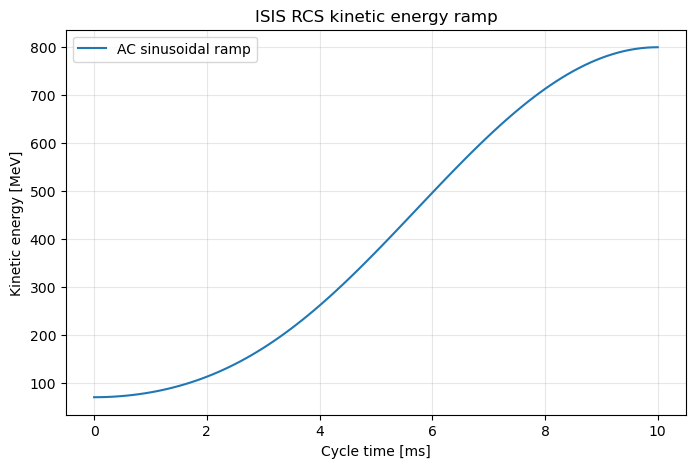

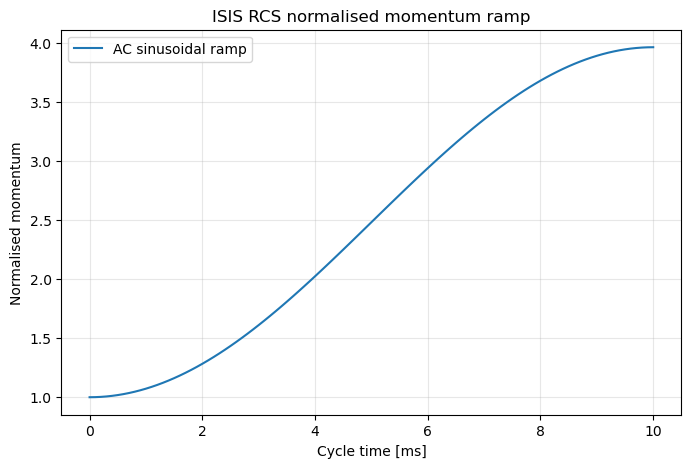

In [14]:
# ============================================================
# 12. Plot example
# ============================================================

df_plot = ramp.full_cycle_dataframe(intervals=100)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_plot["cycle_time_ms"],
    df_plot["kinetic_energy_MeV"],
    label="AC sinusoidal ramp",
)

ax.set_xlabel("Cycle time [ms]")
ax.set_ylabel("Kinetic energy [MeV]")
ax.set_title("ISIS RCS kinetic energy ramp")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_plot["cycle_time_ms"],
    df_plot["normalised_momentum"],
    label="AC sinusoidal ramp",
)

ax.set_xlabel("Cycle time [ms]")
ax.set_ylabel("Normalised momentum")
ax.set_title("ISIS RCS normalised momentum ramp")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [15]:
# ============================================================
# 13. Error handling checks
# ============================================================

print("\nError handling checks")
print("---------------------")

try:
    bad_ramp = RCSRamp(
        top_energy_MeV=70.0,
        injection_energy_MeV=70.0,
    )
except ValueError as err:
    print("Correctly caught top energy error:")
    print(err)

try:
    bad_ramp = RCSRamp(
        top_energy_MeV=800.0,
        cycle_start_ms=10.0,
        cycle_end_ms=0.0,
    )
except ValueError as err:
    print("\nCorrectly caught cycle time error:")
    print(err)


Error handling checks
---------------------
Correctly caught top energy error:
top_energy_MeV must be greater than injection_energy_MeV.

Correctly caught cycle time error:
cycle_end_ms must be greater than cycle_start_ms.


In [16]:
# ============================================================
# 14. Final compact validation table
# ============================================================

validation_times = [0.0, 2.5, 5.0, 7.5, 10.0]
validation_df = ramp.dataframe_at(validation_times)

validation_df = validation_df[
    [
        "cycle_time_ms",
        "kinetic_energy_MeV",
        "momentum_GeV_c",
        "gamma",
        "beta",
        "brho_Tm",
        "normalised_momentum",
    ]
]

print("\nCompact validation table")
print("------------------------")
display(validation_df)

print("\nAll cycle_time.py examples and tests completed successfully.")


Compact validation table
------------------------


,cycle_time_ms,kinetic_energy_MeV,momentum_GeV_c,gamma,beta,brho_Tm,normalised_momentum
0,0.0,70.000000,0.369132,1.074605,0.366103,1.231290,1.000000
1,2.5,139.032523,0.529368,1.148179,0.491382,1.765782,1.434091
2,5.0,373.140216,0.916214,1.397689,0.698647,3.056160,2.482079
3,7.5,667.442156,1.303059,1.711352,0.811514,4.346538,3.530068
4,10.0,800.000000,1.463296,1.852631,0.841811,4.881030,3.964159



All cycle_time.py examples and tests completed successfully.
